# Create input

In [1]:
base_path = "/path/to/scratch/pacific/roms/"

In [2]:
import xarray as xr

In [3]:
ds_grid = xr.open_dataset("../../INPUT/pacmed12_grd.nc")

In [4]:
ds_tracer_flux_1999 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_1999.nc", decode_timedelta=False, chunks={"time": 1})
ds_tracer_flux_2000 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_2000.nc", decode_timedelta=False, chunks={"time": 1})
ds_tracer_flux_2021 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_2021.nc", decode_timedelta=False, chunks={"time": 1})

In [5]:
ds_tracer_flux_2000

<xarray.Dataset> Size: 271GB
Dimensions:  (time: 764, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time     (time) float64 6kB 1.826e+03 1.826e+03 ... 1.858e+03 1.858e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/25)
    VI7      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI9      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI10     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI11     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    SS7      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ...       ...
    EC11     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP7      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP9      (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP11     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>

## Rivers without BGC

Note that all partitioned files are the same.

In [6]:
ds = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_partitioned_40x16/pacmed12_riv_MARBL.001.nc")

In [7]:
ds = ds.isel(ntracers=slice(None, 2))

In [8]:
ds

<xarray.Dataset> Size: 476kB
Dimensions:       (ntracers: 2, river_time: 349, nriver: 85)
Coordinates:
  * ntracers      (ntracers) int64 16B 1 2
  * river_time    (river_time) float32 1kB -17.0 14.0 ... 1.038e+04 1.041e+04
Dimensions without coordinates: nriver
Data variables:
    river_volume  (ntracers, river_time, nriver) float32 237kB ...
    river_tracer  (ntracers, river_time, nriver) float32 237kB ...

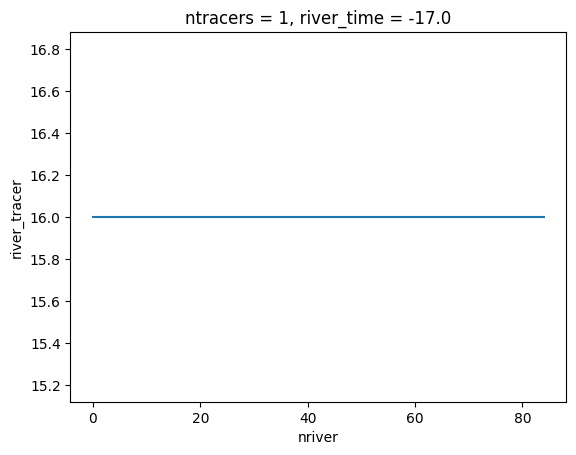

In [9]:
ds.river_tracer.isel(ntracers=0, river_time=0).plot()

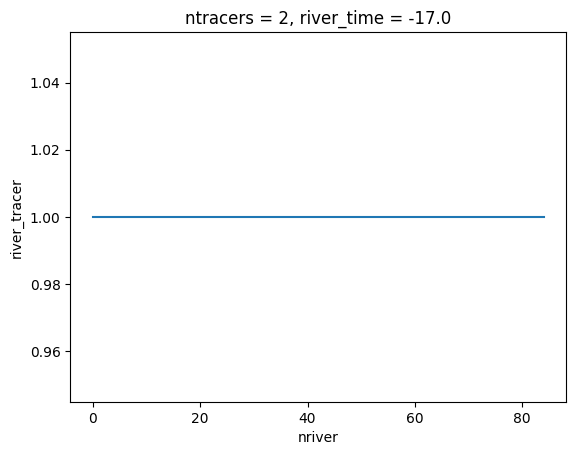

In [10]:
ds.river_tracer.isel(ntracers=1, river_time=0).plot()

In [9]:
ds.to_netcdf(f"{base_path}/INPUT/pacmed12_riv.nc")

/tmp/ipykernel_1493725/326389038.py:2: UserWarning: String dimension naming mismatch on variable None. 'string11' provided by encoding, but data has length of '4'. Using 'string4' instead of 'string11' to prevent possible naming clash.
To silence this warning either remove 'char_dim_name' from encoding or provide a fitting name.
  ds.to_netcdf(f"{base_path}/INPUT/pacmed12_river_forcing_no_bgc.nc")
/tmp/ipykernel_1493725/326389038.py:2: UserWarning: String dimension naming mismatch on variable None. 'string43' provided by encoding, but data has length of '21'. Using 'string21' instead of 'string43' to prevent possible naming clash.
To silence this warning either remove 'char_dim_name' from encoding or provide a fitting name.
  ds.to_netcdf(f"{base_path}/INPUT/pacmed12_river_forcing_no_bgc.nc")


## Atmospheric forcing with tracer release

In [6]:
tracer_names = [
    "VI7", "VI8", "VI10",
    "BC7", "BC8", "BC10",
    "EC7", "EC8", "EC10",
    "JP7", "JP8", "JP10"
]

In [7]:
ds_1999 = xr.Dataset()
ds_2000 = xr.Dataset()
ds_2021 = xr.Dataset()

In [8]:
for ds, ds_tracer_flux in zip([ds_1999, ds_2000, ds_2021], [ds_tracer_flux_1999, ds_tracer_flux_2000, ds_tracer_flux_2021]):
    
    ds["time"] = ds_tracer_flux["time"]
    
    for tracer_name in tracer_names:
        forcing = ds_tracer_flux[tracer_name]
        ds[f"{tracer_name}_CONSERVED_flx"] = forcing
        ds[f"{tracer_name}_CONSERVED_flx"].attrs = forcing.attrs
        ds[f"{tracer_name}_DEFICIT_flx"] = forcing
        ds[f"{tracer_name}_DEFICIT_flx"].attrs = forcing.attrs
        ds[f"{tracer_name}_OAE_DEF_flx"] = 0 * forcing
        ds[f"{tracer_name}_OAE_DEF_flx"].attrs = forcing.attrs

In [9]:
ds_1999

<xarray.Dataset> Size: 10GB
Dimensions:             (time: 20, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time                (time) float64 160B 1.825e+03 1.825e+03 ... 1.826e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/36)
    VI7_CONSERVED_flx   (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_DEFICIT_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ...                  ...
    JP8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_CONSERVED_flx  (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_DEFICIT_flx    (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_OAE_DEF_flx    (time, eta_rho, xi_rho) float64 284MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>

In [10]:
ds_2000

<xarray.Dataset> Size: 390GB
Dimensions:             (time: 764, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time                (time) float64 6kB 1.826e+03 1.826e+03 ... 1.858e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/36)
    VI7_CONSERVED_flx   (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_DEFICIT_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ...                  ...
    JP8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_CONSERVED_flx  (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_DEFICIT_flx    (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_OAE_DEF_flx    (time, eta_rho, xi_rho) float64 11GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>

In [11]:
ds_2021

<xarray.Dataset> Size: 510MB
Dimensions:             (time: 1, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time                (time) float64 8B 9.528e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/36)
    VI7_CONSERVED_flx   (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_DEFICIT_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI7_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    VI8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ...                  ...
    JP8_CONSERVED_flx   (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_DEFICIT_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP8_OAE_DEF_flx     (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_CONSERVED_flx  (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_DEFICIT_flx    (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    JP10_OAE_DEF_flx    (time, eta_rho, xi_rho) float64 14MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>

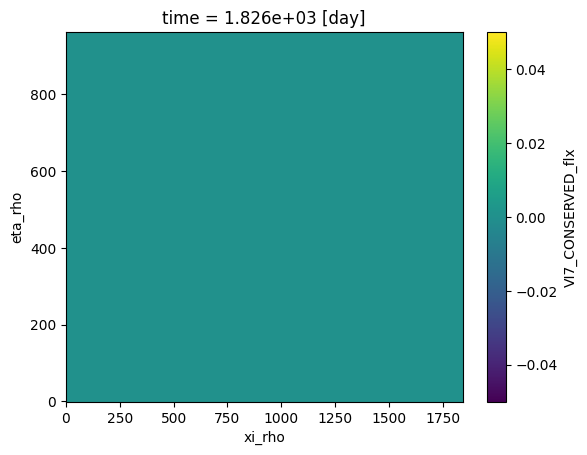

In [12]:
ds_1999["VI7_CONSERVED_flx"].isel(time=-1).plot()

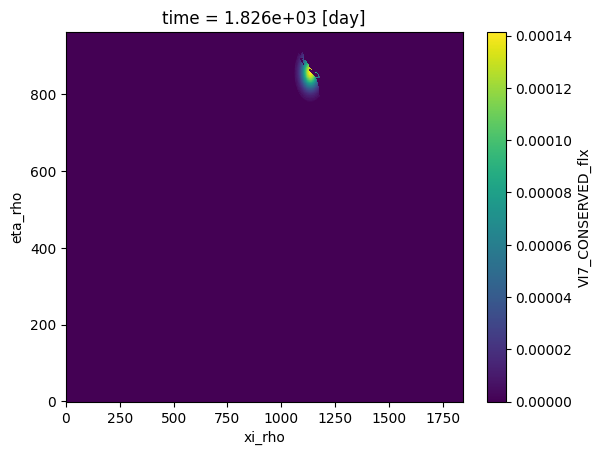

In [13]:
ds_2000["VI7_CONSERVED_flx"].isel(time=0).plot()

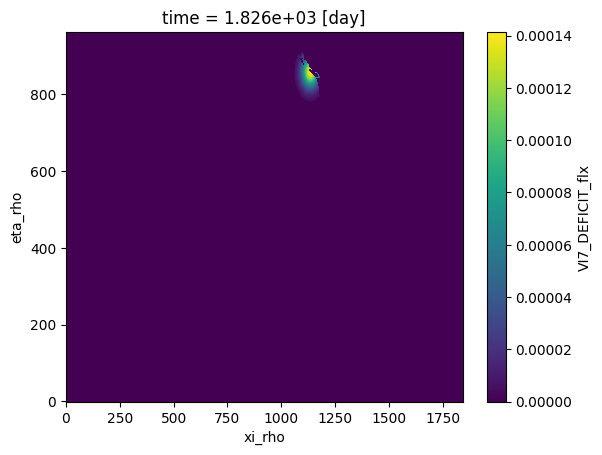

In [14]:
ds_2000["VI7_DEFICIT_flx"].isel(time=0).plot()

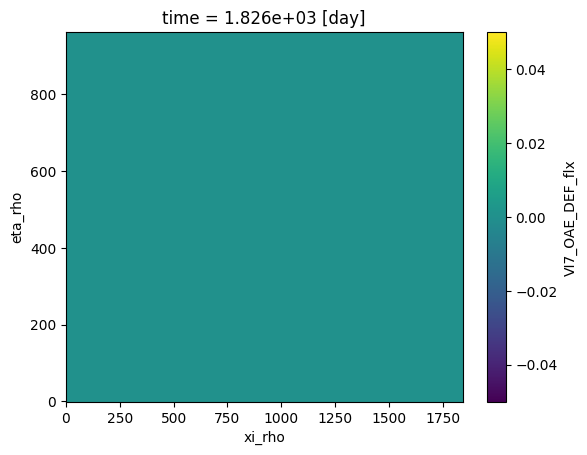

In [15]:
ds_2000["VI7_OAE_DEF_flx"].isel(time=0).plot()

In [16]:
ds_1999.to_netcdf(f"{base_path}/INPUT/roms_tracer_surf_flux_1999.nc")
ds_2000.to_netcdf(f"{base_path}/INPUT/roms_tracer_surf_flux_2000.nc")
ds_2021.to_netcdf(f"{base_path}/INPUT/roms_tracer_surf_flux_2021.nc")

## Boundary forcing

In [17]:
from roms_tools import Grid

In [18]:
grid = Grid.from_file("../../INPUT/pacmed12_grd.nc", theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-02-12 10:33:09 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-02-12 10:33:09 - INFO - Total time: 0.003 seconds
2026-02-12 10:33:09 - INFO - ================================================================================================


In [19]:
grid.ds

<xarray.Dataset> Size: 246MB
Dimensions:       (eta_rho: 962, xi_rho: 1842, eta_psi: 961, xi_psi: 1841,
                   xi_u: 1841, eta_v: 961, eta_coarse: 482, xi_coarse: 922,
                   s_rho: 100, s_w: 101)
Coordinates:
    lon_rho       (eta_rho, xi_rho) float64 14MB ...
    lat_rho       (eta_rho, xi_rho) float64 14MB ...
    lat_u         (eta_rho, xi_u) float64 14MB -45.89 -45.86 ... 39.81 39.79
    lon_u         (eta_rho, xi_u) float64 14MB -249.2 -249.1 ... -45.96 -45.87
    lat_v         (eta_v, xi_rho) float64 14MB -45.87 -45.84 ... 39.76 39.74
    lon_v         (eta_v, xi_rho) float64 14MB -249.2 -249.1 ... -45.93 -45.83
    lat_coarse    (eta_coarse, xi_coarse) float64 4MB -45.96 -45.9 ... 39.8
    lon_coarse    (eta_coarse, xi_coarse) float64 4MB 110.8 111.0 ... 314.2
Dimensions without coordinates: eta_rho, xi_rho, eta_psi, xi_psi, xi_u, eta_v,
                                eta_coarse, xi_coarse, s_rho, s_w
Data variables: (12/19)
    spherical     |S1 1B ...
    angle         (eta_rho, xi_rho) float64 14MB ...
    h             (eta_rho, xi_rho) float64 14MB ...
    hraw          (eta_rho, xi_rho) float64 14MB ...
    f             (eta_rho, xi_rho) float64 14MB ...
    pm            (eta_rho, xi_rho) float64 14MB ...
    ...            ...
    angle_coarse  (eta_coarse, xi_coarse) float64 4MB 0.3732 0.3731 ... -0.3045
    mask_coarse   (eta_coarse, xi_coarse) int32 2MB 1 1 1 1 1 1 ... 0 0 0 0 0 0
    sigma_r       (s_rho) float32 400B -0.995 -0.985 -0.975 ... -0.015 -0.005
    Cs_r          (s_rho) float32 400B -0.9995 -0.9983 ... -0.0001214 -1.349e-05
    sigma_w       (s_w) float32 404B -1.0 -0.99 -0.98 -0.97 ... -0.02 -0.01 0.0
    Cs_w          (s_w) float32 404B -1.0 -0.999 -0.9976 ... -5.396e-05 0.0
Attributes:
    title:          ROMS grid by Easy Grid. Settings: nx: 1840 ny: 960 xsize:...
    date:           08-Aug-2008
    type:           ROMS grid produced by Easy Grid
    VertCoordType:  NEW
    straddle:       False
    theta_s:        6.0
    theta_b:        6.0
    hc:             250.0

In [20]:
ds_ref_1999 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_partitioned_40x16/pacmed12_bry_1999.400.nc", decode_times=False, decode_timedelta=False)
ds_ref_2000 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_partitioned_40x16/pacmed12_bry_2000.400.nc", decode_times=False, decode_timedelta=False)
ds_ref_2021 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_partitioned_40x16/pacmed12_bry_2021.400.nc", decode_times=False, decode_timedelta=False)

In [21]:
ds_1999 = xr.Dataset()
ds_2000 = xr.Dataset()
ds_2021 = xr.Dataset()

In [22]:
bdry_coords = {
    "south": {"eta_rho": 0},
    "east": {"xi_rho": -1},
    "north": {"eta_rho": -1},
    "west": {"xi_rho": 0},
}

In [23]:
for ds, ds_ref in zip([ds_1999, ds_2000, ds_2021], [ds_ref_1999, ds_ref_2000, ds_ref_2021]):
    ds["bry_time"] = ds_ref["bry_time"]
    for tracer_name in tracer_names:
        for direction in ["south", "east", "north", "west"]:
            tmp = xr.zeros_like(ds_tracer_flux_1999[tracer_name].isel(**bdry_coords[direction]).isel(time=0)).drop_vars("time") * grid.ds.s_rho

            ds[f"{tracer_name}_CONSERVED_{direction}"] = tmp * ds_ref.bry_time
            ds[f"{tracer_name}_DEFICIT_{direction}"] = tmp * ds_ref.bry_time
            ds[f"{tracer_name}_OAE_DEF_{direction}"] = tmp * ds_ref.bry_time


In [24]:
ds_1999 = ds_1999.transpose("time", "s_rho", "xi_rho", "eta_rho")
ds_2000 = ds_2000.transpose("time", "s_rho", "xi_rho", "eta_rho")
ds_2021 = ds_2021.transpose("time", "s_rho", "xi_rho", "eta_rho")

In [25]:
ds_1999

<xarray.Dataset> Size: 59GB
Dimensions:               (time: 365, xi_rho: 1842, s_rho: 100, eta_rho: 962)
Dimensions without coordinates: time, xi_rho, s_rho, eta_rho
Data variables: (12/145)
    bry_time              (time) float32 1kB ...
    VI7_CONSERVED_south   (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    VI7_DEFICIT_south     (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    VI7_OAE_DEF_south     (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    VI7_CONSERVED_east    (time, s_rho, eta_rho) float64 281MB dask.array<chunksize=(365, 100, 962), meta=np.ndarray>
    VI7_DEFICIT_east      (time, s_rho, eta_rho) float64 281MB dask.array<chunksize=(365, 100, 962), meta=np.ndarray>
    ...                    ...
    JP10_CONSERVED_north  (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    JP10_DEFICIT_north    (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    JP10_OAE_DEF_north    (time, s_rho, xi_rho) float64 538MB dask.array<chunksize=(365, 100, 1842), meta=np.ndarray>
    JP10_CONSERVED_west   (time, s_rho, eta_rho) float64 281MB dask.array<chunksize=(365, 100, 962), meta=np.ndarray>
    JP10_DEFICIT_west     (time, s_rho, eta_rho) float64 281MB dask.array<chunksize=(365, 100, 962), meta=np.ndarray>
    JP10_OAE_DEF_west     (time, s_rho, eta_rho) float64 281MB dask.array<chunksize=(365, 100, 962), meta=np.ndarray>

In [26]:
ds_1999.to_netcdf(f"{base_path}/INPUT/roms_bry_tracers_1999.nc")
ds_2000.to_netcdf(f"{base_path}/INPUT/roms_bry_tracers_2000.nc")
ds_2021.to_netcdf(f"{base_path}/INPUT/roms_bry_tracers_2021.nc")